# 3D tracking of the curve across video frames
This stage uses xy coordinates from synced left and right video frames of the same objects. It triangulates each point to produce xyz coordinates for the object (e.g. fish individual) for each video frame. Prior to this step, cameras should be calibrated in time and space. 

## Epipolar lines check

Loading calibration data from: C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\notebooks\stereovideo_calibration\stereo_matrices.npz


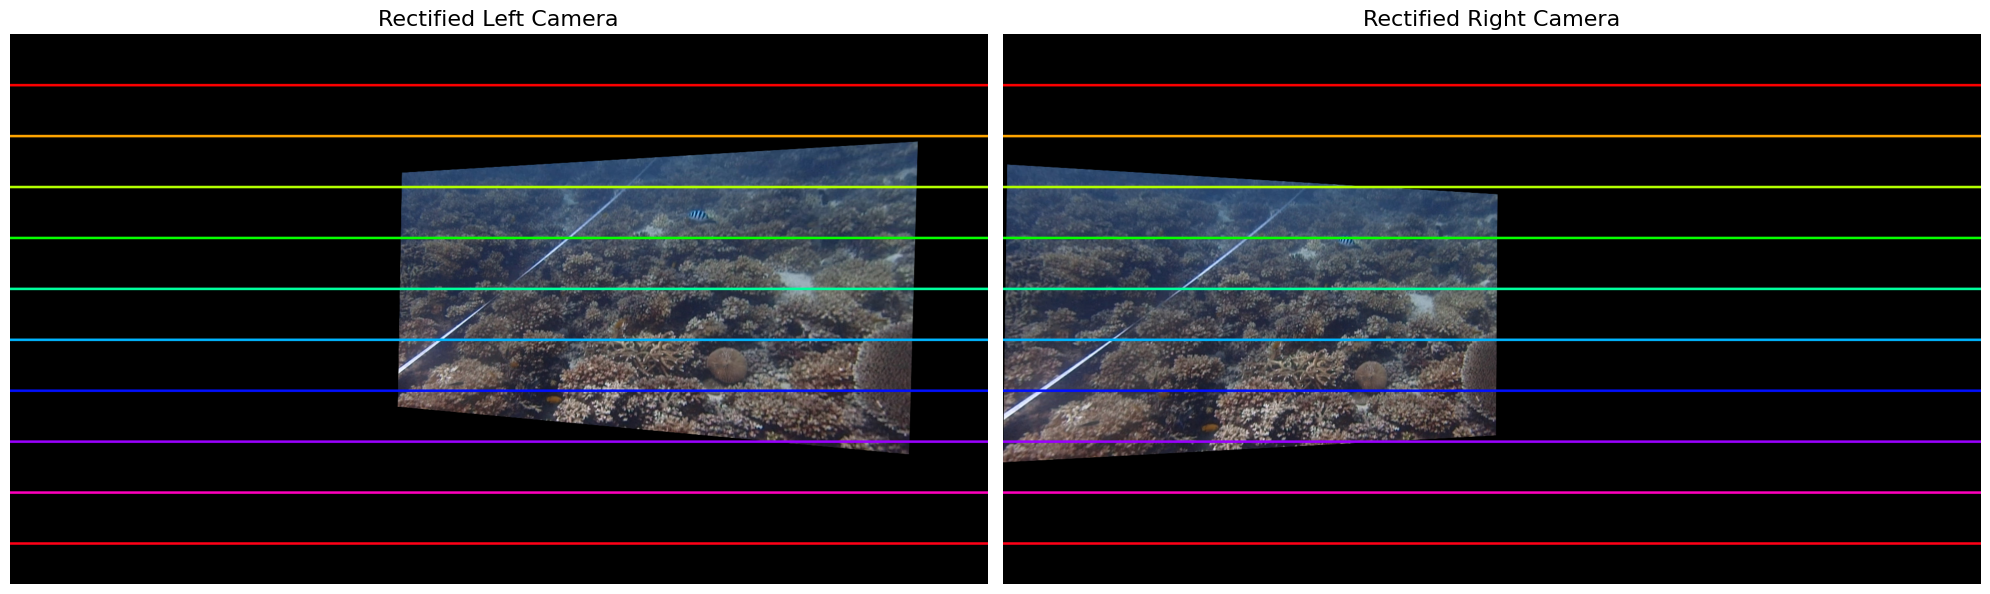

In [3]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_rectified_epipolar_lines(left_img_path, right_img_path, calibration_npz_path):
    """
    Loads stereo calibration matrices, rectifies the images to make them mathematically parallel,
    and plots horizontal epipolar lines to visually validate the calibration.
    """
    # 1. Load the images
    img_left = cv2.imread(left_img_path)
    img_right = cv2.imread(right_img_path)
    
    if img_left is None or img_right is None:
        print("Error: Could not load one or both images. Check the paths.")
        return

    # Convert from BGR (OpenCV) to RGB (Matplotlib)
    img_left_rgb = cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB)
    img_right_rgb = cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB)
    
    h, w = img_left_rgb.shape[:2]

    # 2. Load the Calibration Matrices
    print(f"Loading calibration data from: {calibration_npz_path}")
    archive = np.load(calibration_npz_path)
    
    try:
        K1, K2 = archive['K1'], archive['K2']
        R, T = archive['R'], archive['T']
    except KeyError:
        print("Error: Missing K1, K2, R, or T in the .npz file.")
        return

    # Distortion coefficients (defaults to zeros if not saved in your calibration step)
    dist1 = archive['dist1'] if 'dist1' in archive.files else np.zeros((1, 5))
    dist2 = archive['dist2'] if 'dist2' in archive.files else np.zeros((1, 5))

    # 3. Compute Rectification Transforms (Bouguet's Algorithm)
    # This computes the rotation matrices (R1, R2) needed to align both camera optical axes.
    # alpha=0 crops out the black borders caused by the warping.
    R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(
        K1, dist1, K2, dist2, (w, h), R, T, alpha=1
    )

    # 4. Generate the Undistortion and Rectification Maps
    # These maps tell OpenCV exactly where to move every single pixel to flatten the image.
    map1x, map1y = cv2.initUndistortRectifyMap(K1, dist1, R1, P1, (w, h), cv2.CV_32FC1)
    map2x, map2y = cv2.initUndistortRectifyMap(K2, dist2, R2, P2, (w, h), cv2.CV_32FC1)

    # 5. Apply the Maps to warp the images
    rect_left = cv2.remap(img_left_rgb, map1x, map1y, cv2.INTER_LINEAR)
    rect_right = cv2.remap(img_right_rgb, map2x, map2y, cv2.INTER_LINEAR)

    # 6. Draw Horizontal Epipolar Lines
    # Because the images are now rectified, epipolar lines are strictly horizontal.
    # We will draw a line every 100 pixels.
    line_interval = 100
    colors = plt.cm.hsv(np.linspace(0, 1, h // line_interval)).tolist()
    
    for idx, y in enumerate(range(line_interval, h, line_interval)):
        # Convert matplotlib color (0-1) to RGB (0-255) for OpenCV
        color = (np.array(colors[idx][:3]) * 255).astype(int).tolist()
        
        cv2.line(rect_left, (0, y), (w, y), color, thickness=3)
        cv2.line(rect_right, (0, y), (w, y), color, thickness=3)

    # 7. Display the result in the Jupyter Notebook
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    axes[0].imshow(rect_left)
    axes[0].set_title("Rectified Left Camera", fontsize=16)
    axes[0].axis('off')

    axes[1].imshow(rect_right)
    axes[1].set_title("Rectified Right Camera", fontsize=16)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Define your paths here
    # LEFT_IMAGE = r'C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\raw\\UMT\\Images 3-190716\\St7-Teluk Air\\TG4 Black(L) images st7 (T.A)\\St7_75-100m(L).MOV-8.jpg'
    # RIGHT_IMAGE = r'C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\raw\\UMT\\Images 3-190716\\St7-Teluk Air\\TG4 Red(R) images st7 (T.A)\\St7_75-100m(R).MOV-8.jpg'


    LEFT_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\detection_recalibrated\UMT-Recalibrated-1-Meters-Right-Frames\UMT-Recalibrated-1-Meters-Right-Frame-43.jpg'
    RIGHT_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\UMT\detection_recalibrated\UMT-Recalibrated-1-Meters-Right-Frames\UMT-Recalibrated-1-Meters-Right-Frame-43.jpg'

    CALIBRATION_FILE = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\notebooks\stereovideo_calibration\stereo_matrices.npz"
    
    # Run the visualizer
    plot_rectified_epipolar_lines(LEFT_IMAGE, RIGHT_IMAGE, CALIBRATION_FILE)

Loading calibration data from: C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\notebooks\stereovideo_calibration\stereo_matrices.npz


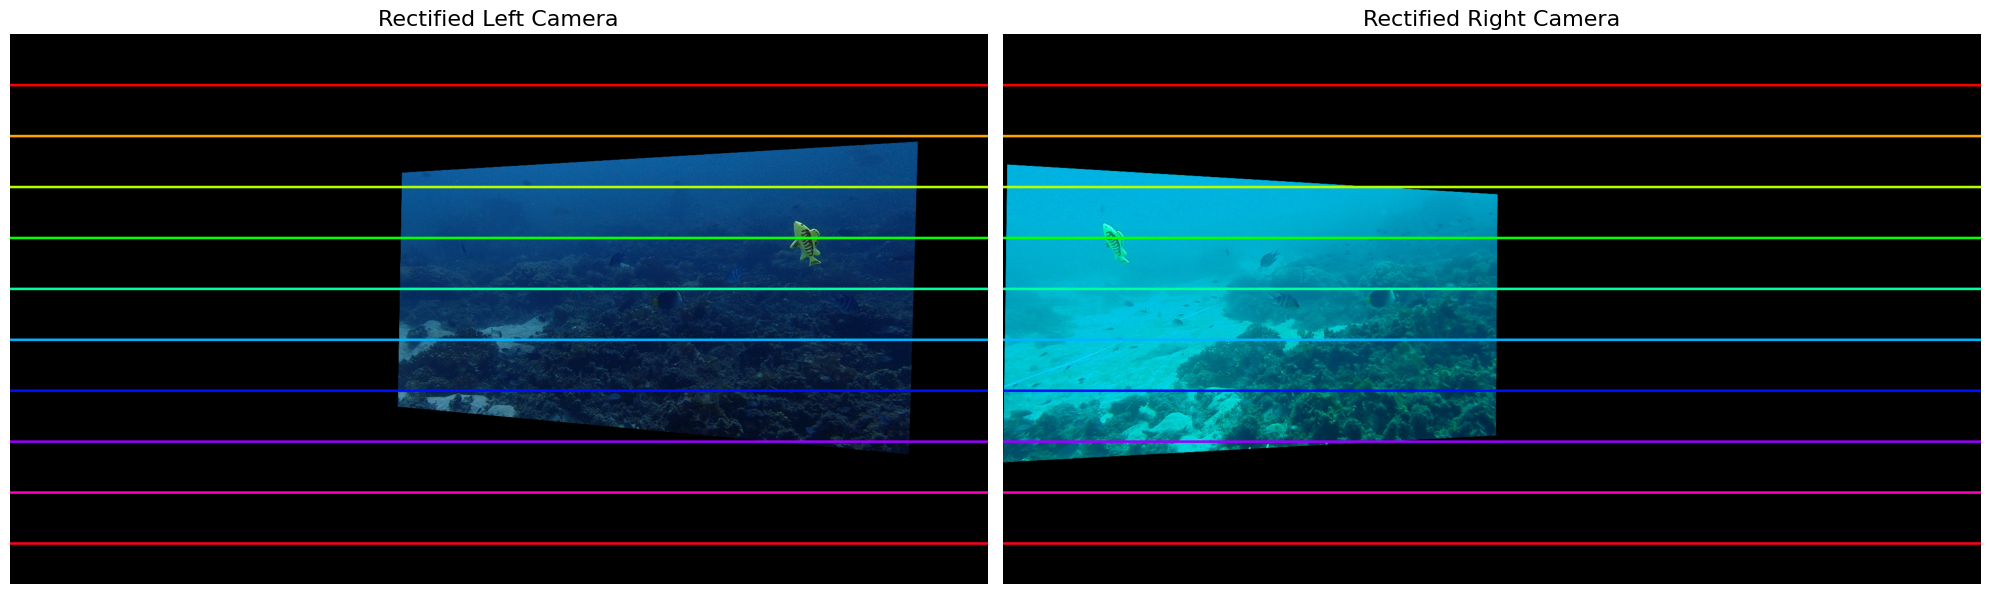

In [9]:
if __name__ == "__main__":
    # Define your paths here
    # LEFT_IMAGE = r'C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\raw\\UMT\\Images 3-190716\\St7-Teluk Air\\TG4 Black(L) images st7 (T.A)\\St7_75-100m(L).MOV-8.jpg'
    # RIGHT_IMAGE = r'C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\raw\\UMT\\Images 3-190716\\St7-Teluk Air\\TG4 Red(R) images st7 (T.A)\\St7_75-100m(R).MOV-8.jpg'


    LEFT_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\calibration-v2\selection_for_ground_truth\LEFT\ground_truth_1-Left-Frame-248.jpg'
    RIGHT_IMAGE = r'C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\calibration-v2\selection_for_ground_truth\RIGHT\ground_truth_1-Right-Frame-248.jpg'

    CALIBRATION_FILE = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\notebooks\stereovideo_calibration\stereo_matrices.npz"
    
    # Run the visualizer
    plot_rectified_epipolar_lines(LEFT_IMAGE, RIGHT_IMAGE, CALIBRATION_FILE)

In [4]:

import glob


if __name__ == "__main__":
    # Define your paths here
    # LEFT_IMAGE = r'C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\raw\\UMT\\Images 3-190716\\St7-Teluk Air\\TG4 Black(L) images st7 (T.A)\\St7_75-100m(L).MOV-8.jpg'
    # RIGHT_IMAGE = r'C:\\Users\\Work Mode Big Dog\\OneDrive - ECAM\\Bureau\\ERASMUS\\PROJECT\\CODE\\data\\raw\\UMT\\Images 3-190716\\St7-Teluk Air\\TG4 Red(R) images st7 (T.A)\\St7_75-100m(R).MOV-8.jpg'


    LEFT_IMAGE = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\calibration-v2\selection_for_ground_truth\LEFT\ground_truth_1-Left-Frame-248.jpg"
    RIGHT_IMAGE = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\data\processed\calibration-v2\selection_for_ground_truth\RIGHT\ground_truth_1-Right-Frame-248.jpg"

    CALIBRATION_FILE = r"C:\Users\Work Mode Big Dog\OneDrive - ECAM\Bureau\ERASMUS\PROJECT\CODE\notebooks\stereovideo_calibration\stereo_matrices.npz"
    
    # Run the visualizer
    plot_rectified_epipolar_lines(LEFT_IMAGE, RIGHT_IMAGE, CALIBRATION_FILE)

Error: Could not load one or both images. Check the paths.
